<a href="https://colab.research.google.com/github/Gabriel-Arsego/Garsego_64061/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [37]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import models, layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

Settings

In [38]:
max_features = 10000
maxlen = 150
embedding_dim = 50

train_sizes = [100, 500, 1000, 5000]

Loading Data

In [39]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = imdb.load_data(num_words=max_features)

Downloading and Loading GloVe

In [40]:
!wget https://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip glove.6B.50d.txt
!ls

--2026-04-20 01:48:00--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-20 01:48:00--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.2’

glove.6B.zip.2      100%[===================>] 822.24M  2.97MB/s    in 2m 54s  

2026-04-20 01:50:55 (4.72 MB/s) - ‘glove.6B.zip.2’ saved [862182613/862182613]

Archive:  glove.6B.zip
replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: glove.6B.50d.txt  

In [41]:
embeddings_index = {}

with open('glove.6B.50d.txt') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

Building Embedding Matrix

In [42]:
word_index = imdb.get_word_index()

embedding_matrix = np.zeros((max_features, embedding_dim))

for word, i in word_index.items():
    if i < max_features and i < len(embedding_matrix):
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

To Save Results

In [43]:
results = []

Loop Through All Training Sizes

In [44]:
for train_size in train_sizes:
    print(f"\n=== Running for train_size = {train_size} ===")

    # Prepare data
    x_train = x_train_full[:train_size]
    y_train = y_train_full[:train_size]

    x_val = x_test_full[:10000]
    y_val = y_test_full[:10000]

    x_test = x_test_full[10000:]
    y_test = y_test_full[10000:]

    x_train = pad_sequences(x_train, maxlen=maxlen)
    x_val = pad_sequences(x_val, maxlen=maxlen)
    x_test = pad_sequences(x_test, maxlen=maxlen)

    # Model 1: Learned Embedding
    model = models.Sequential()
    model.add(layers.Embedding(max_features, 32, input_length=maxlen))
    model.add(layers.SimpleRNN(32))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        x_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(x_val, y_val),
        verbose=1
    )

    val_acc_embed = history.history['val_accuracy'][-1]

    # Model 2: GloVe
    model_glove = models.Sequential()
    model_glove.add(layers.Embedding(
        max_features,
        embedding_dim,
        input_length=maxlen,
        weights=[embedding_matrix]
    ))
    model_glove.add(layers.SimpleRNN(32))
    model_glove.add(layers.Dense(1, activation='sigmoid'))

    model_glove.layers[0].trainable = False

    model_glove.compile(optimizer='rmsprop',
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

    history_glove = model_glove.fit(
        x_train, y_train,
        epochs=10,
        batch_size=32,
        validation_data=(x_val, y_val),
        verbose=1
    )

    val_acc_glove = history_glove.history['val_accuracy'][-1]

    # Save results
    results.append((train_size, val_acc_embed, val_acc_glove))


=== Running for train_size = 100 ===
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5800 - loss: 0.6801 - val_accuracy: 0.5026 - val_loss: 0.6997
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 0.9800 - loss: 0.5149 - val_accuracy: 0.4992 - val_loss: 0.7028
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step - accuracy: 0.9900 - loss: 0.4080 - val_accuracy: 0.4949 - val_loss: 0.7115
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 475ms/step - accuracy: 1.0000 - loss: 0.3103 - val_accuracy: 0.5003 - val_loss: 0.7151
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 403ms/step - accuracy: 1.0000 - loss: 0.2519 - val_accuracy: 0.5068 - val_loss: 0.7167
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 403ms/step - accuracy: 1.0000 - loss: 0.1860 - val_accuracy: 0.5069 - val_loss: 0.7319
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 1.0000 - loss: 0.1370 - val_accuracy: 0.4998 - val_loss: 0.7349
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 1.0000 - loss: 0.113

Result Table

In [45]:
print("\nFinal Results:")
print("Train Size | Embedding | GloVe | Better")

for train_size, acc_e, acc_g in results:
    better = "GloVe" if acc_g > acc_e else "Embedding"
    print(f"{train_size:<10} {acc_e:.4f}     {acc_g:.4f}     {better}")


Final Results:
Train Size | Embedding | GloVe | Better
100        0.4997     0.4923     Embedding
500        0.5069     0.5096     GloVe
1000       0.5426     0.5246     Embedding
5000       0.5475     0.5466     Embedding


Graph for Comparisons

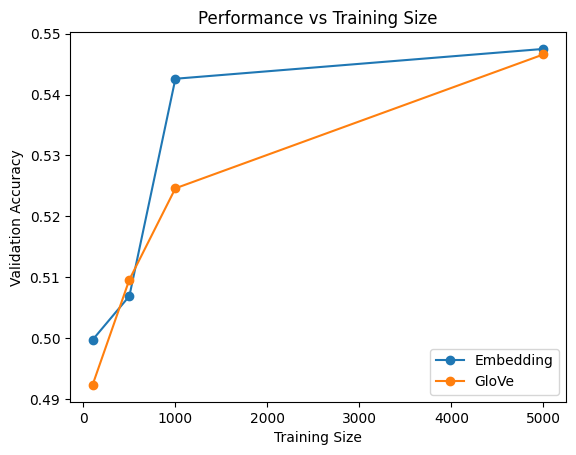

In [46]:
sizes = [r[0] for r in results]
embed_acc = [r[1] for r in results]
glove_acc = [r[2] for r in results]

plt.plot(sizes, embed_acc, marker='o', label='Embedding')
plt.plot(sizes, glove_acc, marker='o', label='GloVe')

plt.title('Performance vs Training Size')
plt.xlabel('Training Size')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()